# SHELL pipeline visual validation

This notebook inspects the local WSI pipeline in stages:

1. Load a slide and build the analysis thumbnail.
2. Display the tissue mask and tissue-density diagnostics.
3. Display EHO channels and stain-normalisation inputs.
4. Inspect mask-aware, row-specific tile placement.
5. Run one tile through Gaussian sliding-window inference.
6. Optionally run the full slide and compare the output at full and zoomed views.

The full-slide run is opt-in because it can take several minutes.

In [9]:
from pathlib import Path
import logging
import sys

import matplotlib.pyplot as plt
import numpy as np
import pyvips

# Without this, shell.infer_wsi's INFO logs (tissue %, tile counts, and the
# new per-tile progress messages) are silently dropped, so a long real-model
# run prints nothing at all and looks frozen even while it's still working.
logging.basicConfig(level=logging.INFO, format='%(levelname)s %(name)s: %(message)s')

# Make the notebook work from the repository root or from notebooks/.
repo = Path.cwd()
if not (repo / 'src').exists():
    repo = Path.cwd().parent
sys.path.insert(0, str(repo / 'src'))

from shell.infer_wsi import (
    _mask_aware_tile_positions,
    _tile_positions,
    infer_wsi,
    get_mask_aware_tile_positions,
    _get_global_1d_schedule,
)
from shell.inference import GaussianMaskAwareInference
from shell.model import CLASS_NAMES, TILE_SIZE, build_model
from shell.transforms import apply_eho_chunked, detect_background, estimate_stain_params

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['image.interpolation'] = 'nearest'

# viridis is a continuous colormap, so adjacent label values blend together
# and are hard to tell apart. Use one distinct, fixed color per class instead.
from matplotlib.colors import BoundaryNorm, ListedColormap

LABEL_COLORS = [
    '#000000',  # 0 background
    '#00e5ff',  # 1 inner (lumen)
    '#e60049',  # 2 outer (epithelium)
    '#dcdcdc',  # 3 white / glass
    '#8c6d31',  # 4 background tissue (stroma)
    '#ff00ff',  # 5 epithelial nuclei
    '#7d3ac1',  # 6 other nuclei
    '#ffd700',  # 7 urethra
    '#ff8c00',  # 8 edge epithelium
]
LABEL_CMAP = ListedColormap(LABEL_COLORS)
LABEL_NORM = BoundaryNorm(np.arange(len(LABEL_COLORS) + 1) - 0.5, len(LABEL_COLORS))


def show_labels(axis, label_image, title):
    """Render a label map with the shared discrete colormap and a legend."""
    im = axis.imshow(label_image, cmap=LABEL_CMAP, norm=LABEL_NORM, interpolation='nearest')
    axis.set_title(title)
    present = sorted(int(v) for v in np.unique(label_image))
    handles = [
        plt.Rectangle((0, 0), 1, 1, color=LABEL_COLORS[v]) for v in present
    ]
    labels = [CLASS_NAMES.get(v, str(v)) for v in present]
    axis.legend(
        handles, labels, loc='upper left', bbox_to_anchor=(1.01, 1.0),
        fontsize=8, borderaxespad=0,
    )
    return im

In [2]:
# Configuration. Change only this cell for another slide.
import torch

INPUT = repo / 'LR10_N102_S15_HE.jp2'
OUTPUT = repo / 'profile_output' / f'{INPUT.stem}_visual_labels.jp2'
SAVE_EHO = repo / 'profile_output' / f'{INPUT.stem}_visual_eho.jp2'
SAVE_RAW = repo / 'profile_output' / f'{INPUT.stem}_visual_raw.jp2'
MOUNT_MPP = None  # Set the source MPP when the slide has no metadata.
TARGET_MPP = 1.0
TILE_SIZE = TILE_SIZE[0]
MIN_TISSUE_FRAC = 0.05
MIN_OVERLAP = 0.25  # between-tile overlap band, as a fraction of tile size
MAX_OVERLAP = 0.5   # the scheduler picks the fewest tiles within this band
GAUSSIAN_OVERLAP = 0.5  # within-tile MONAI sliding-window overlap
EDGE_THICKNESS_PX = 1024
RUN_FULL_INFERENCE = True
SAVE_INTERMEDIATES = False  # EHO/raw-band JP2s roughly double peak RAM; opt-in only.
MODEL_PATH = None  # Runtime inference is ONNX-only; None uses the bundled ONNX model.

# CPU inference of this model at 2048x2048 is ~33x slower than CUDA per tile.
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

assert INPUT.exists(), f'Missing slide: {INPUT}'
print(f'Input: {INPUT}')
print(f'Output: {OUTPUT}')
print(f'Device: {DEVICE}')
print(f'Tile size: {TILE_SIZE}  min tissue: {MIN_TISSUE_FRAC:.1%}')
print(f'Overlap band: [{MIN_OVERLAP:.0%}, {MAX_OVERLAP:.0%}]  edge thickness: {EDGE_THICKNESS_PX}px')

Input: /home/coder/shell/LR10_N102_S15_HE.jp2
Output: /home/coder/shell/profile_output/LR10_N102_S15_HE_visual_labels.jp2
Device: cuda
Tile size: 2048  min tissue: 5.0%
Overlap band: [25%, 50%]  edge thickness: 1024px


## 1. Slide and analysis thumbnail

The production path uses a bounded thumbnail for tissue detection and stain estimation.

INFO pyvips: VIPS: residual reducev by 0.0930571
INFO pyvips: VIPS: shrinkv by 5
INFO pyvips: VIPS: reducev: 13 point mask
INFO pyvips: VIPS: reducev: using vector path
INFO pyvips: VIPS: residual reduceh by 0.0930571
INFO pyvips: VIPS: shrinkh by 5
INFO pyvips: VIPS: reduceh: 13 point mask
INFO pyvips: VIPS: reduceh: using vector path


INFO pyvips: VIPS: threadpool completed with 11 workers


Full image: 17,867 x 22,008
Thumbnail: 1,663 x 2,048


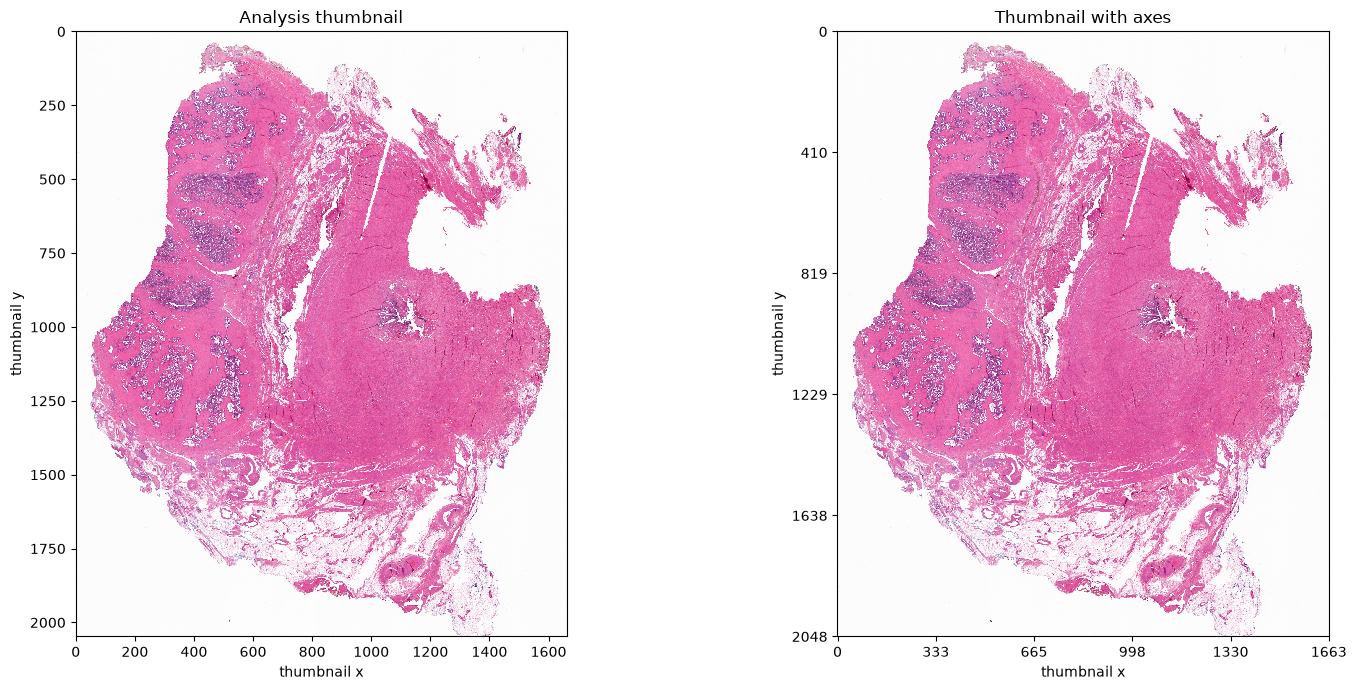

In [3]:
pyvips.concurrency_set(12)
slide = pyvips.Image.new_from_file(str(INPUT), access='random')
height, width = slide.height, slide.width
analysis_scale = min(1.0, 2048 / max(height, width))
thumbnail = np.ascontiguousarray(
    slide.resize(analysis_scale).numpy()[:, :, :3]
)
print(f'Full image: {width:,} x {height:,}')
print(f'Thumbnail: {thumbnail.shape[1]:,} x {thumbnail.shape[0]:,}')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(thumbnail)
axes[0].set_title('Analysis thumbnail')
axes[1].imshow(thumbnail)
axes[1].set_title('Thumbnail with axes')
axes[1].set_xticks(np.linspace(0, thumbnail.shape[1], 6))
axes[1].set_yticks(np.linspace(0, thumbnail.shape[0], 6))
for axis in axes:
    axis.set_xlabel('thumbnail x')
    axis.set_ylabel('thumbnail y')
plt.tight_layout()

## 2. Tissue mask and density

The mask is shown both as a binary image and as a red overlay. The histogram helps explain why tissue-pixel coverage and skipped-tile percentage are different quantities.

Raw tissue pixels: 50.4%
Clean tissue pixels: 50.4%


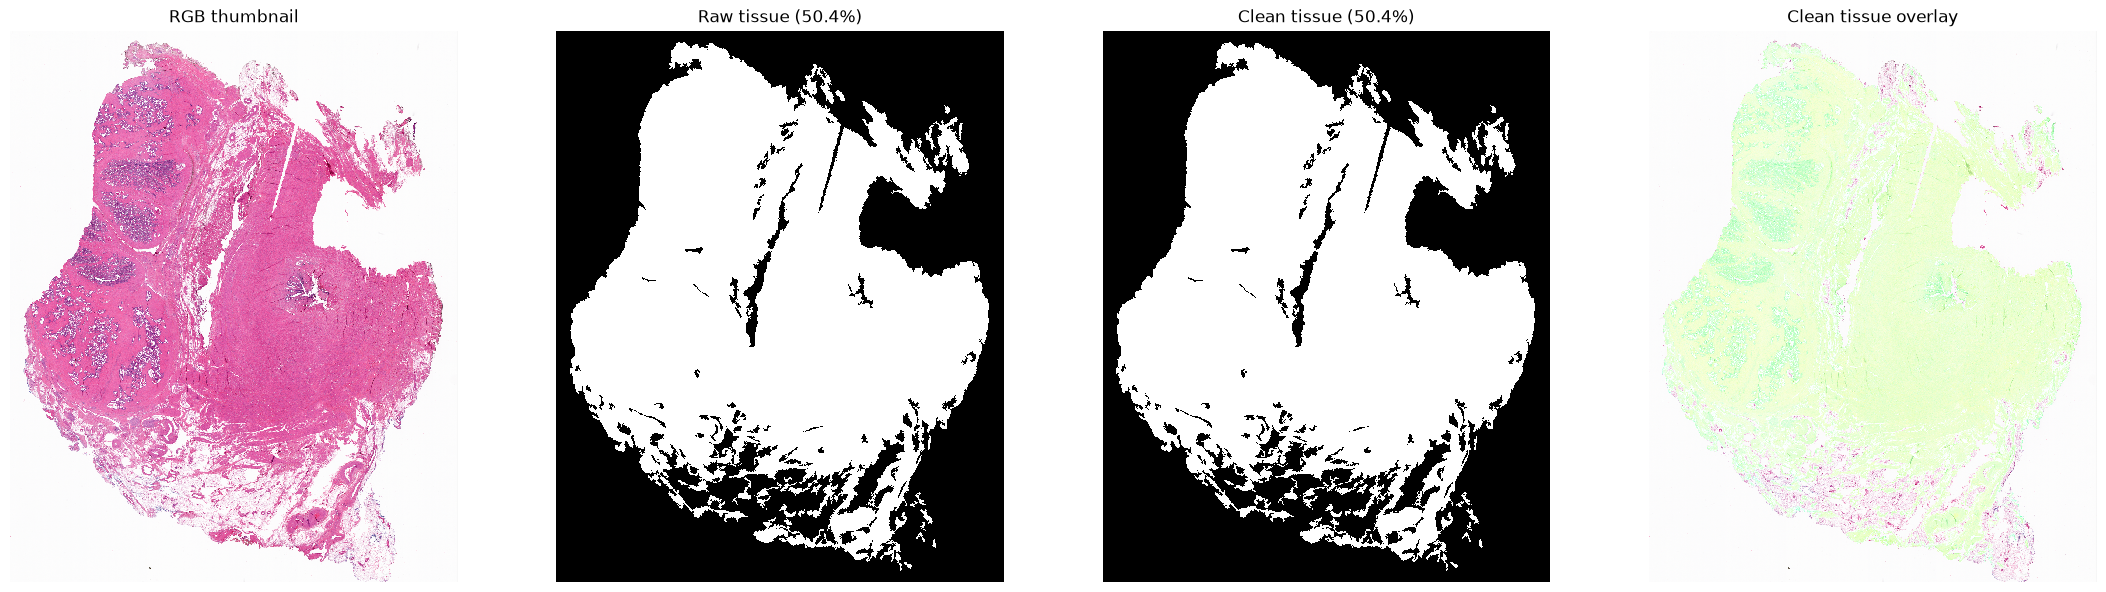

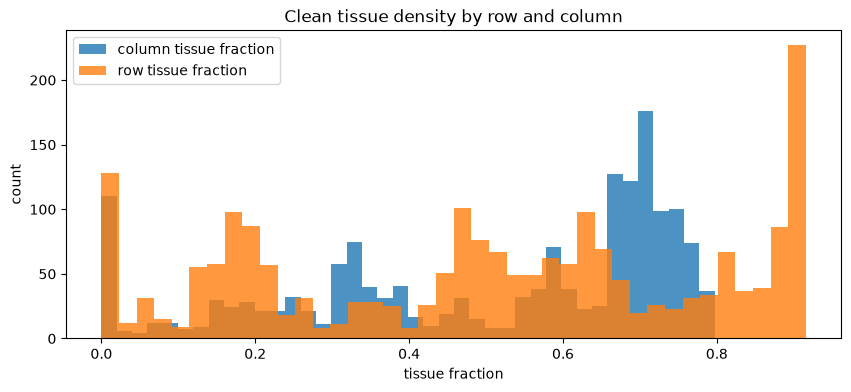

In [4]:
background_mask = detect_background(thumbnail)
tissue_thumbnail = ~background_mask
print(f'Raw tissue pixels: {tissue_thumbnail.mean():.1%}')

# The detector now removes small background speckles and fills only bounded holes.
# Show both the raw threshold result and the cleaned production mask.
from skimage.morphology import remove_small_holes, remove_small_objects
clean_tissue_thumbnail = remove_small_holes(
    remove_small_objects(tissue_thumbnail, max_size=256),
    max_size=256,
)
print(f'Clean tissue pixels: {clean_tissue_thumbnail.mean():.1%}')

overlay = thumbnail.copy()
overlay[clean_tissue_thumbnail] = (
    0.65 * overlay[clean_tissue_thumbnail] + np.array([90, 220, 100])
).clip(0, 255)
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
axes[0].imshow(thumbnail)
axes[0].set_title('RGB thumbnail')
axes[1].imshow(tissue_thumbnail, cmap='gray')
axes[1].set_title(f'Raw tissue ({tissue_thumbnail.mean():.1%})')
axes[2].imshow(clean_tissue_thumbnail, cmap='gray')
axes[2].set_title(f'Clean tissue ({clean_tissue_thumbnail.mean():.1%})')
axes[3].imshow(overlay.astype(np.uint8))
axes[3].set_title('Clean tissue overlay')
for axis in axes:
    axis.axis('off')
plt.tight_layout()

plt.figure(figsize=(10, 4))
plt.hist(clean_tissue_thumbnail.mean(axis=0), bins=40, alpha=0.8, label='column tissue fraction')
plt.hist(clean_tissue_thumbnail.mean(axis=1), bins=40, alpha=0.8, label='row tissue fraction')
plt.xlabel('tissue fraction')
plt.ylabel('count')
plt.legend()
plt.title('Clean tissue density by row and column')
plt.show()

## 3. EHO and stain parameters

These are the three channels used by the model: eosin, hematoxylin, and optical density.

{'Io': 250.27757798900006, 'e_idx': 0, 'h_idx': 1, 'e_lo': -0.005144640803337097, 'e_hi': 0.5111805200576782, 'h_lo': -0.0035613342188298702, 'h_hi': 0.43152865767478943, 'od_lo': 0.0, 'od_hi': 0.34630152583122253}


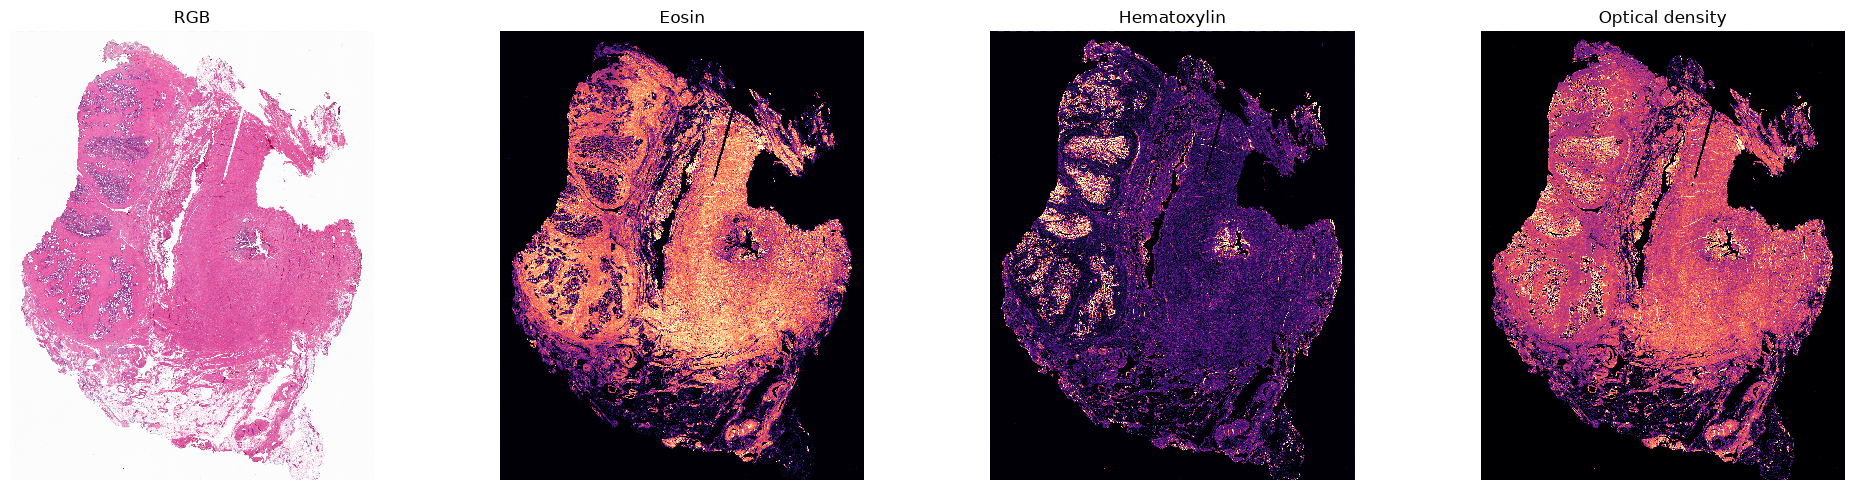

In [5]:
stain_background = ~tissue_thumbnail
stain_params = estimate_stain_params(thumbnail, bg_mask=stain_background)
eho_thumbnail = apply_eho_chunked(
    thumbnail,
    chunk_rows=thumbnail.shape[0],
    **stain_params,
)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(thumbnail)
axes[0].set_title('RGB')
for index, name in enumerate(('Eosin', 'Hematoxylin', 'Optical density'), start=1):
    axes[index].imshow(eho_thumbnail[:, :, index - 1], cmap='magma')
    axes[index].set_title(name)
for axis in axes:
    axis.axis('off')
plt.tight_layout()
print({key: value for key, value in stain_params.items() if key not in {'w_est'}})

## 4. Mask-aware row-specific tile schedule

The full-resolution mask is only used for diagnostics here. Green rectangles are scheduled tiles; red rectangles are the margin/core overlap boundaries. Notice that x-starts can change from one row band to the next.

Global grid envelope: 154 possible tiles
X overlap: 578px (28.2%)
Y overlap: 581px (28.4%)


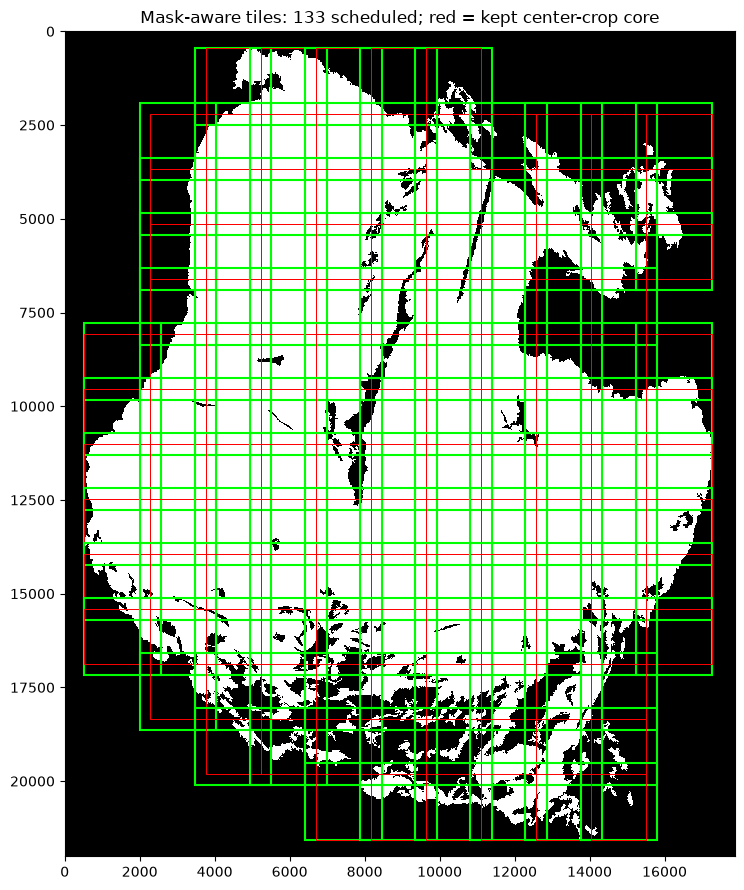

In [11]:
# 1. Handle tuple TILE_SIZE if necessary
tile_size_int = TILE_SIZE[0] if isinstance(TILE_SIZE, tuple) else TILE_SIZE

# 2. Determine the global tissue bounds and full grid to extract the overlap
row_any = tissue_full.any(axis=1)
col_any = tissue_full.any(axis=0)
y_start, y_end = int(np.argmax(row_any)), int(height - np.argmax(row_any[::-1]))
x_start, x_end = int(np.argmax(col_any)), int(width - np.argmax(col_any[::-1]))

y_coords = _get_global_1d_schedule(y_start, y_end, tile_size_int, MIN_OVERLAP, MAX_OVERLAP, height)
x_coords = _get_global_1d_schedule(x_start, x_end, tile_size_int, MIN_OVERLAP, MAX_OVERLAP, width)

# Global overlap is the tile size minus the distance to the next tile
y_overlap_px = tile_size_int - (y_coords[1] - y_coords[0]) if len(y_coords) > 1 else 0
x_overlap_px = tile_size_int - (x_coords[1] - x_coords[0]) if len(x_coords) > 1 else 0

print(f'Global grid envelope: {len(y_coords) * len(x_coords)} possible tiles')
print(f'X overlap: {x_overlap_px}px ({x_overlap_px / tile_size_int:.1%})')
print(f'Y overlap: {y_overlap_px}px ({y_overlap_px / tile_size_int:.1%})')

# 3. Fetch the final mask-filtered coordinates
tile_positions = get_mask_aware_tile_positions(
    tissue_full, tile_size_int, MIN_OVERLAP, MAX_OVERLAP, MIN_TISSUE_FRAC
)

fig, axis = plt.subplots(figsize=(16, 9))
axis.imshow(tissue_full, cmap='gray')

# Grid boundaries for calculating edge-trimming on the red boxes
min_x, max_x = x_coords[0], x_coords[-1]
min_y, max_y = y_coords[0], y_coords[-1]

for x0, y0 in tile_positions:
    tile_w = min(tile_size_int, width - x0)
    tile_h = min(tile_size_int, height - y0)
    
    # Outer bounding box (full tile)
    axis.add_patch(plt.Rectangle(
        (x0, y0), tile_w, tile_h, fill=False,
        edgecolor='lime', linewidth=1.5,
    ))
    
    # Red inner rectangle (center-crop core)
    # Trimmed by half the global overlap on each interior side. 
    # Edge tiles do not get trimmed on their outermost boundary.
    core_x = x0 + (x_overlap_px // 2 if x0 > min_x else 0)
    core_y = y0 + (y_overlap_px // 2 if y0 > min_y else 0)
    
    core_w = tile_w - (x_overlap_px // 2 if x0 > min_x else 0) - (
        (x_overlap_px - x_overlap_px // 2) if x0 < max_x else 0
    )
    core_h = tile_h - (y_overlap_px // 2 if y0 > min_y else 0) - (
        (y_overlap_px - y_overlap_px // 2) if y0 < max_y else 0
    )
    
    axis.add_patch(plt.Rectangle(
        (core_x, core_y), core_w, core_h, fill=False,
        edgecolor='red', linewidth=0.7,
    ))

axis.set_title(f'Mask-aware tiles: {len(tile_positions)} scheduled; red = kept center-crop core')
axis.set_xlim(0, width)
axis.set_ylim(height, 0)
plt.tight_layout()
plt.show()

## 5. One tile: RGB, EHO, tissue, and Gaussian prediction

This cell loads the model only when needed. It uses the first scheduled tile containing tissue.

INFO pyvips: VIPS: threadpool completed with 4 workers
INFO pyvips: VIPS: threadpool completed with 2 workers
INFO pyvips: VIPS: threadpool completed with 4 workers
INFO pyvips: VIPS: threadpool completed with 3 workers
INFO pyvips: VIPS: threadpool completed with 5 workers
INFO pyvips: VIPS: threadpool completed with 5 workers
INFO pyvips: VIPS: threadpool completed with 3 workers
INFO pyvips: VIPS: threadpool completed with 6 workers
INFO pyvips: VIPS: threadpool completed with 6 workers
INFO pyvips: VIPS: threadpool completed with 4 workers
INFO pyvips: VIPS: threadpool completed with 2 workers
INFO pyvips: VIPS: threadpool completed with 6 workers


Selected by predicted epithelium content: [(3467, 10719, 'epi=28.3% tissue=100.0%'), (4938, 6319, 'epi=21.7% tissue=100.0%'), (9348, 9253, 'epi=4.0% tissue=100.0%')]


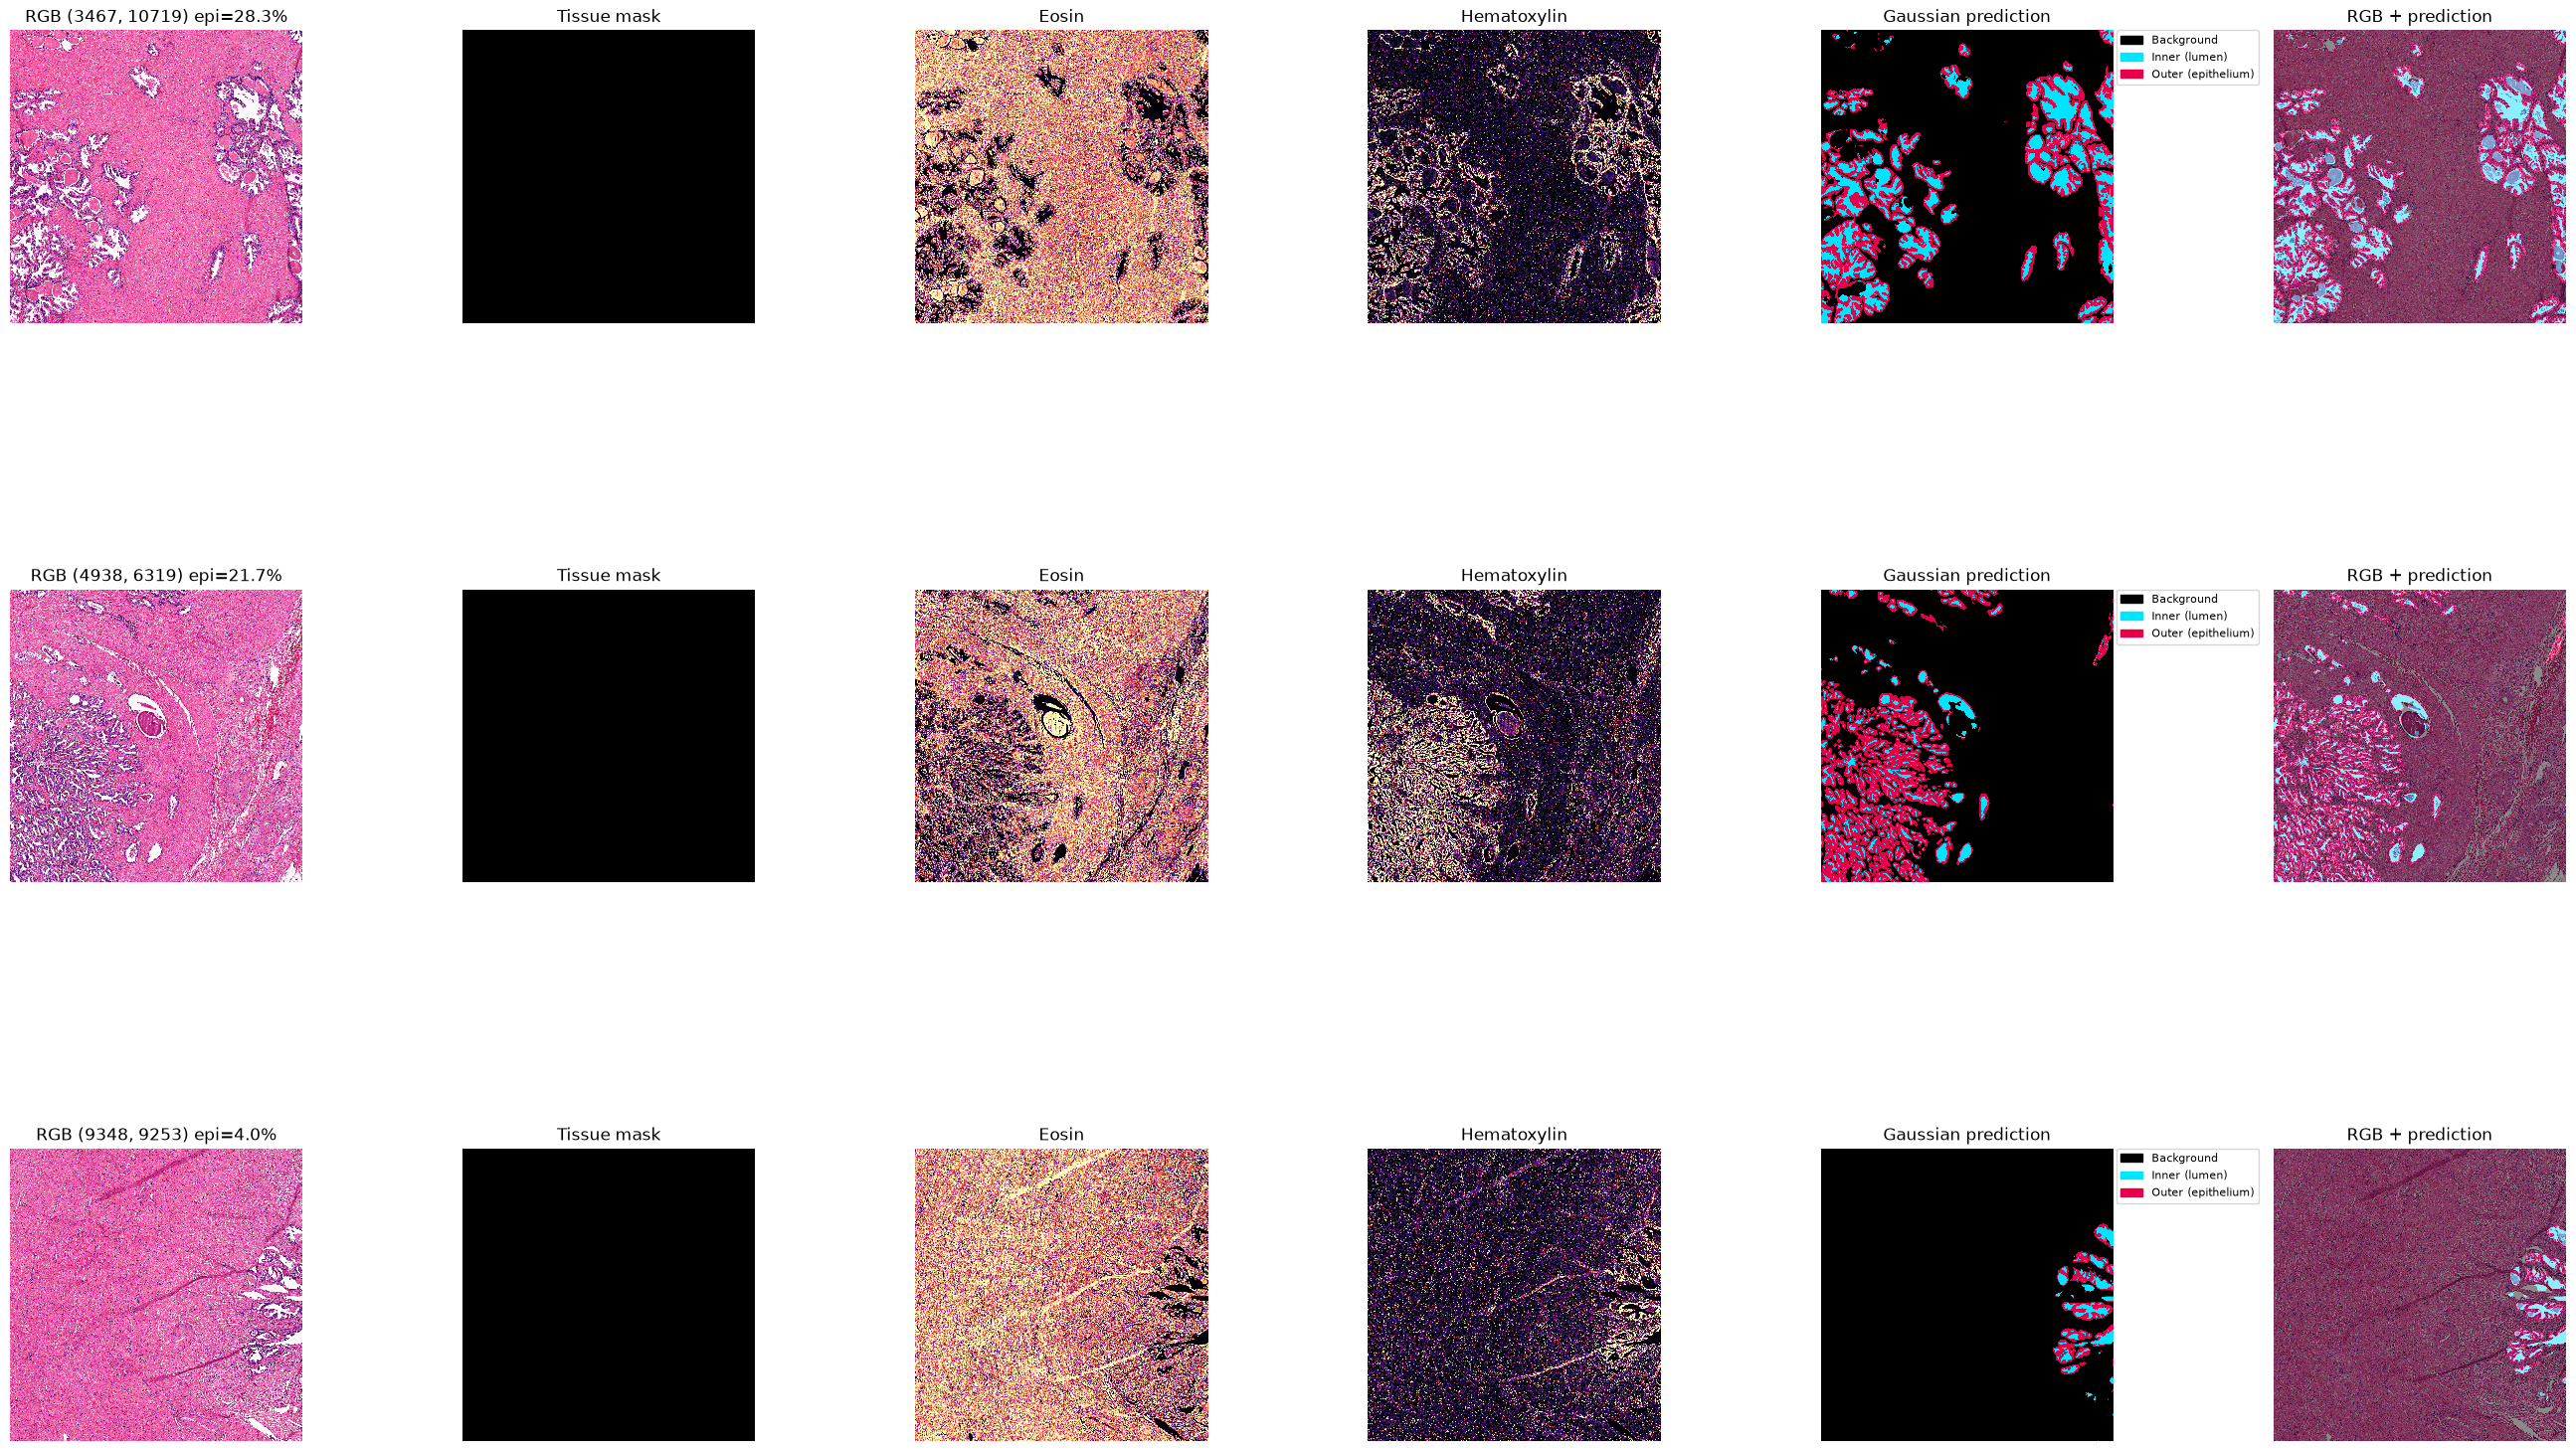

In [ ]:
# Rank candidates by *predicted* epithelium content rather than raw tissue
# density -- a dense-tissue tile can still be uninteresting bare stroma.
candidates = []
height, width = tissue_full.shape

# Get the flat list of 2D coordinates
tile_positions = get_mask_aware_tile_positions(
    tissue_full, TILE_SIZE, MIN_OVERLAP, MAX_OVERLAP, MIN_TISSUE_FRAC
)

for x0, y0 in tile_positions:
    y1_tile = min(y0 + TILE_SIZE, height)
    x1_tile = min(x0 + TILE_SIZE, width)
    density = float(tissue_full[y0:y1_tile, x0:x1_tile].mean())
    distance = ((x0 + TILE_SIZE / 2 - width / 2) ** 2 + (y0 + TILE_SIZE / 2 - height / 2) ** 2) ** 0.5
    candidates.append((density, -distance, x0, y0))
    
shortlist = sorted(candidates, reverse=True)[:12]

model = build_model(MODEL_PATH, DEVICE)
engine = GaussianMaskAwareInference(
    model, DEVICE, roi_size=(TILE_SIZE, TILE_SIZE), overlap=GAUSSIAN_OVERLAP
)

# Cache each probe's RGB/EHO/prediction so the display loop below can reuse
# the top-3 results instead of re-fetching and re-inferencing them.
scored = []
tile_cache = {}
for density, neg_distance, x0, y0 in shortlist:
    h_ = min(TILE_SIZE, height - y0)
    w_ = min(TILE_SIZE, width - x0)
    rgb_probe = np.ascontiguousarray(slide.crop(x0, y0, w_, h_).numpy()[:, :, :3])
    eho_probe = apply_eho_chunked(rgb_probe, chunk_rows=h_, **stain_params)
    inner_probe, outer_probe = engine.predict_tile(eho_probe)
    epithelium_frac = float((inner_probe | outer_probe).mean())
    scored.append((epithelium_frac, density, x0, y0))
    tile_cache[(x0, y0)] = (rgb_probe, eho_probe, inner_probe, outer_probe)
    
selected = sorted(scored, reverse=True)[:3]
print('Selected by predicted epithelium content:', [(x, y, f'epi={e:.1%} tissue={d:.1%}') for e, d, x, y in selected])

fig, axes = plt.subplots(len(selected), 6, figsize=(26, 6 * len(selected)))
axes = np.atleast_2d(axes)
for row, (epithelium_frac, density, sample_x0, sample_y0) in enumerate(selected):
    rgb_tile, tile_eho, inner_tile, outer_tile = tile_cache[(sample_x0, sample_y0)]
    sample_h, sample_w = rgb_tile.shape[:2]
    tile_mask = tissue_full[sample_y0:sample_y0 + sample_h, sample_x0:sample_x0 + sample_w]
    sample_labels = np.zeros_like(inner_tile, dtype=np.uint8)
    sample_labels[outer_tile] = 2
    sample_labels[inner_tile] = 1

    axes[row, 0].imshow(rgb_tile)
    axes[row, 0].set_title(f'RGB ({sample_x0}, {sample_y0}) epi={epithelium_frac:.1%}')
    axes[row, 1].imshow(tile_mask, cmap='gray')
    axes[row, 1].set_title('Tissue mask')
    axes[row, 2].imshow(tile_eho[:, :, 0], cmap='magma')
    axes[row, 2].set_title('Eosin')
    axes[row, 3].imshow(tile_eho[:, :, 1], cmap='magma')
    axes[row, 3].set_title('Hematoxylin')
    show_labels(axes[row, 4], sample_labels, 'Gaussian prediction')
    axes[row, 5].imshow(rgb_tile)
    axes[row, 5].imshow(sample_labels, cmap=LABEL_CMAP, norm=LABEL_NORM, alpha=0.45)
    axes[row, 5].set_title('RGB + prediction')
    for column in range(6):
        axes[row, column].axis('off')
plt.tight_layout()

## 6. Optional full-slide inference

Set `RUN_FULL_INFERENCE = True` in the configuration cell to run the production entry point and write a label TIFF.

In [ ]:
if RUN_FULL_INFERENCE:
    OUTPUT.parent.mkdir(parents=True, exist_ok=True)
    label_map = infer_wsi(
        str(INPUT),
        str(OUTPUT),
        model_path=MODEL_PATH,
        target_mpp=TARGET_MPP,
        mpp=MOUNT_MPP,
        save_eho=str(SAVE_EHO) if SAVE_INTERMEDIATES else None,
        save_raw=str(SAVE_RAW) if SAVE_INTERMEDIATES else None,
        min_tissue_frac=MIN_TISSUE_FRAC,
        min_overlap=MIN_OVERLAP,
        max_overlap=MAX_OVERLAP,
        edge_thickness_px=EDGE_THICKNESS_PX,
        device=DEVICE,
        _model=model,
    )
    print(f'Saved lossless JP2 label map: {OUTPUT}: {label_map.shape}')
    if SAVE_INTERMEDIATES:
        print(f'Saved lossless JP2 EHO: {SAVE_EHO}')
        print(f'Saved lossless JP2 raw bands: {SAVE_RAW}')
else:
    print('Skipped full inference. Set RUN_FULL_INFERENCE=True to enable it.')

/tmp/ipykernel_25953/2198837068.py:3: UserWarning: Could not read um/px metadata from '/home/coder/shell/LR10_N102_S15_HE.jp2'. No resolution scaling will be applied. Use the --mpp flag (or the mpp= parameter) to specify the source resolution manually.
  label_map = infer_wsi(
INFO shell.infer_wsi: Image: 17867 x 22008 px (scaled=False)


## 7. Full-image and zoomed output comparisons

This cell compares the saved label map with the RGB slide at the same coordinates. Set `ZOOM_X` and `ZOOM_Y` to inspect a region of interest.

In [ ]:
if not OUTPUT.exists():
    print(f'{OUTPUT} does not exist yet. Run the previous cell first.')
else:
    # Avoid materialising the full-resolution label map (hundreds of MB to
    # GBs) just to render a small thumbnail and one zoom crop. Both derived
    # views are decoded lazily via pyvips at the size actually needed.
    label_image = pyvips.Image.new_from_file(str(OUTPUT), access='random')
    if label_image.bands > 1:
        label_image = label_image.extract_band(0)

    zoom_x, zoom_y = selected[0][2], selected[0][3]
    zoom_w = min(TILE_SIZE, width - zoom_x)
    zoom_h = min(TILE_SIZE, height - zoom_y)
    rgb_zoom = slide.crop(zoom_x, zoom_y, zoom_w, zoom_h).numpy()[:, :, :3]
    label_zoom = label_image.crop(zoom_x, zoom_y, zoom_w, zoom_h).numpy()
    label_thumb = label_image.resize(analysis_scale, kernel='nearest').numpy()

    fig, axes = plt.subplots(2, 3, figsize=(22, 14))

    axes[0, 0].imshow(thumbnail)
    axes[0, 0].set_title('Full slide overview')
    axes[0, 0].add_patch(plt.Rectangle(
        (zoom_x * analysis_scale, zoom_y * analysis_scale),
        zoom_w * analysis_scale, zoom_h * analysis_scale,
        fill=False, edgecolor='yellow', linewidth=2,
    ))
    show_labels(axes[0, 1], label_thumb, 'Full label map (thumbnail)')
    axes[0, 2].imshow(tissue_full, cmap='gray')
    axes[0, 2].set_title('Full tissue mask')
    axes[1, 0].imshow(rgb_zoom)
    axes[1, 0].set_title(f'Central tissue RGB zoom ({zoom_x}, {zoom_y})')
    show_labels(axes[1, 1], label_zoom, 'Central label zoom')
    axes[1, 2].imshow(rgb_zoom)
    axes[1, 2].imshow(label_zoom, cmap=LABEL_CMAP, norm=LABEL_NORM, alpha=0.45)
    axes[1, 2].set_title('Central RGB + labels')
    for axis in axes.flat:
        axis.axis('off')
    plt.tight_layout()